# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2.Data Loading

In [2]:
df = pd.read_csv("smmh.csv")

df.head()

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


# 3. Check Dataset

In [3]:
df.shape

(481, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    object 
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    object 
 3   3. Relationship Status                                                                                                481 non-null    object 
 4   4. Occup

In [5]:
df.describe()

,1. What is your age?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
count,481.00000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,26.13659,3.553015,3.320166,2.588358,3.349272,3.559252,3.245322,2.831601,2.775468,2.455301,3.255717,3.170478,3.201663
std,9.91511,1.096299,1.328137,1.257059,1.175552,1.283356,1.347105,1.407835,1.056479,1.247739,1.313033,1.256666,1.461619
min,13.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.00000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
50%,22.00000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000
75%,26.00000,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,5.000000
max,91.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# 4.Clean Column Names (IMPORTANT – prevents errors)

In [6]:
df.columns = df.columns.str.strip().str.replace('[^A-Za-z0-9]+', '_', regex=True)

print(df.columns)

Index(['Timestamp', '1_What_is_your_age_', '2_Gender', '3_Relationship_Status',
       '4_Occupation_Status',
       '5_What_type_of_organizations_are_you_affiliated_with_',
       '6_Do_you_use_social_media_',
       '7_What_social_media_platforms_do_you_commonly_use_',
       '8_What_is_the_average_time_you_spend_on_social_media_every_day_',
       '9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose_',
       '10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something_',
       '11_Do_you_feel_restless_if_you_haven_t_used_Social_media_in_a_while_',
       '12_On_a_scale_of_1_to_5_how_easily_distracted_are_you_',
       '13_On_a_scale_of_1_to_5_how_much_are_you_bothered_by_worries_',
       '14_Do_you_find_it_difficult_to_concentrate_on_things_',
       '15_On_a_scale_of_1_5_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media_',
       '16_Following_the_previous_question_how_do_you_feel_abou

# 5.Data Cleaning

In [7]:
#missing values
df.isnull().sum()

Timestamp                                                                                                              0
1_What_is_your_age_                                                                                                    0
2_Gender                                                                                                               0
3_Relationship_Status                                                                                                  0
4_Occupation_Status                                                                                                    0
5_What_type_of_organizations_are_you_affiliated_with_                                                                 30
6_Do_you_use_social_media_                                                                                             0
7_What_social_media_platforms_do_you_commonly_use_                                                                     0
8_What_is_the_average_time_you_s

In [8]:
#Remove duplicates
df = df.drop_duplicates()

In [38]:
# Remove date/time column
df = df.drop(columns=["Timestamp"], errors='ignore')

In [9]:
#Fill missing values
df = df.fillna(method='ffill')

C:\Users\sneha\AppData\Local\Temp\ipykernel_20448\1934366741.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [39]:
print(df.columns)

Index(['1_What_is_your_age_', '2_Gender', '3_Relationship_Status',
       '4_Occupation_Status',
       '5_What_type_of_organizations_are_you_affiliated_with_',
       '6_Do_you_use_social_media_',
       '7_What_social_media_platforms_do_you_commonly_use_',
       '8_What_is_the_average_time_you_spend_on_social_media_every_day_',
       '9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose_',
       '10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something_',
       '11_Do_you_feel_restless_if_you_haven_t_used_Social_media_in_a_while_',
       '12_On_a_scale_of_1_to_5_how_easily_distracted_are_you_',
       '13_On_a_scale_of_1_to_5_how_much_are_you_bothered_by_worries_',
       '14_Do_you_find_it_difficult_to_concentrate_on_things_',
       '15_On_a_scale_of_1_5_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media_',
       '16_Following_the_previous_question_how_do_you_feel_about_these_compa

# 6. Exploratory Data Analysis(EDA)

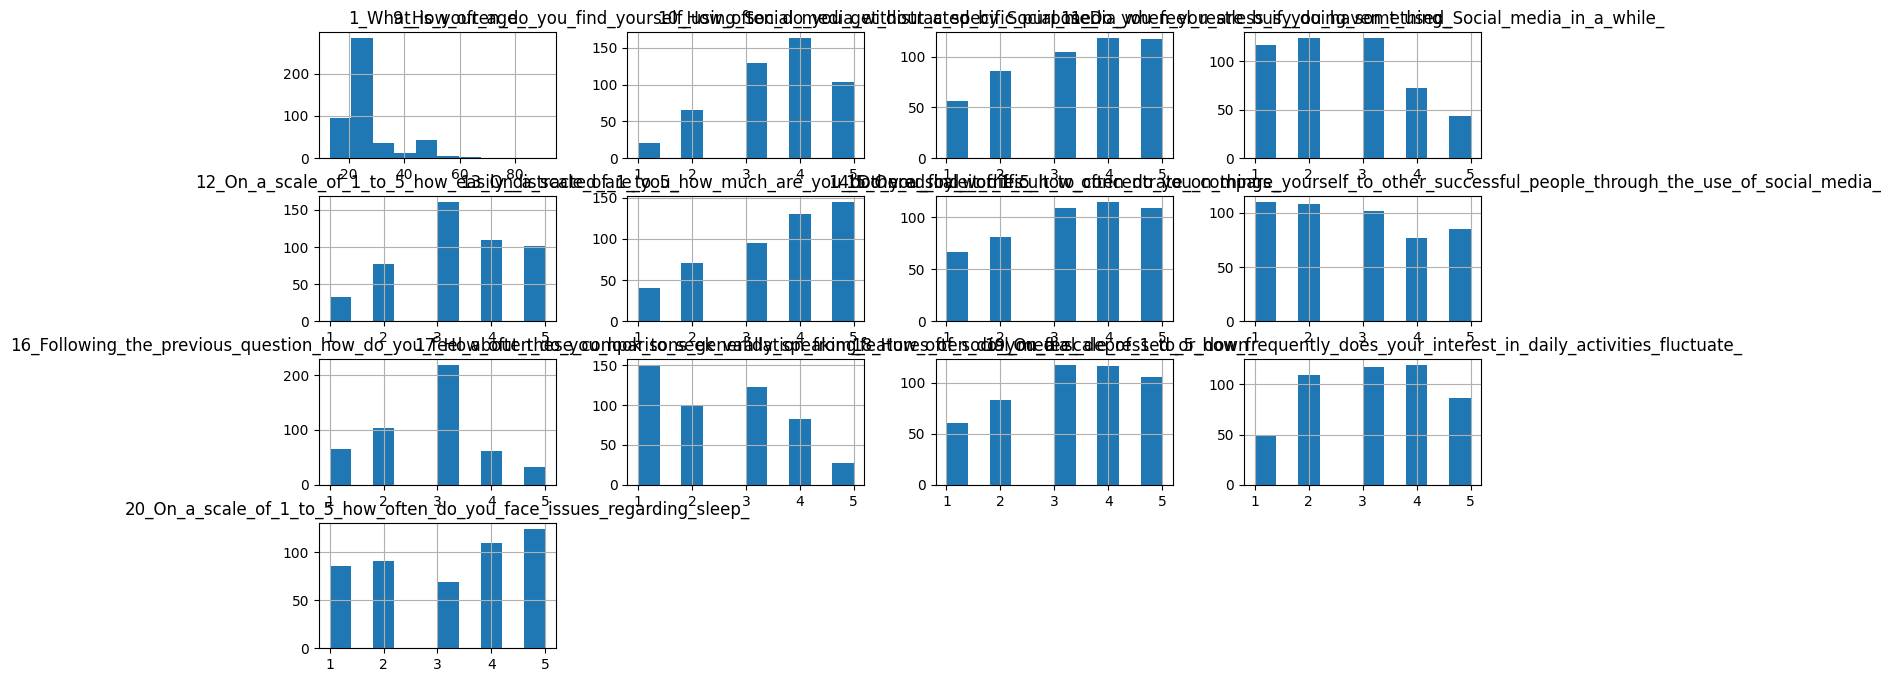

In [10]:
df.hist(figsize=(15,8))
plt.show()

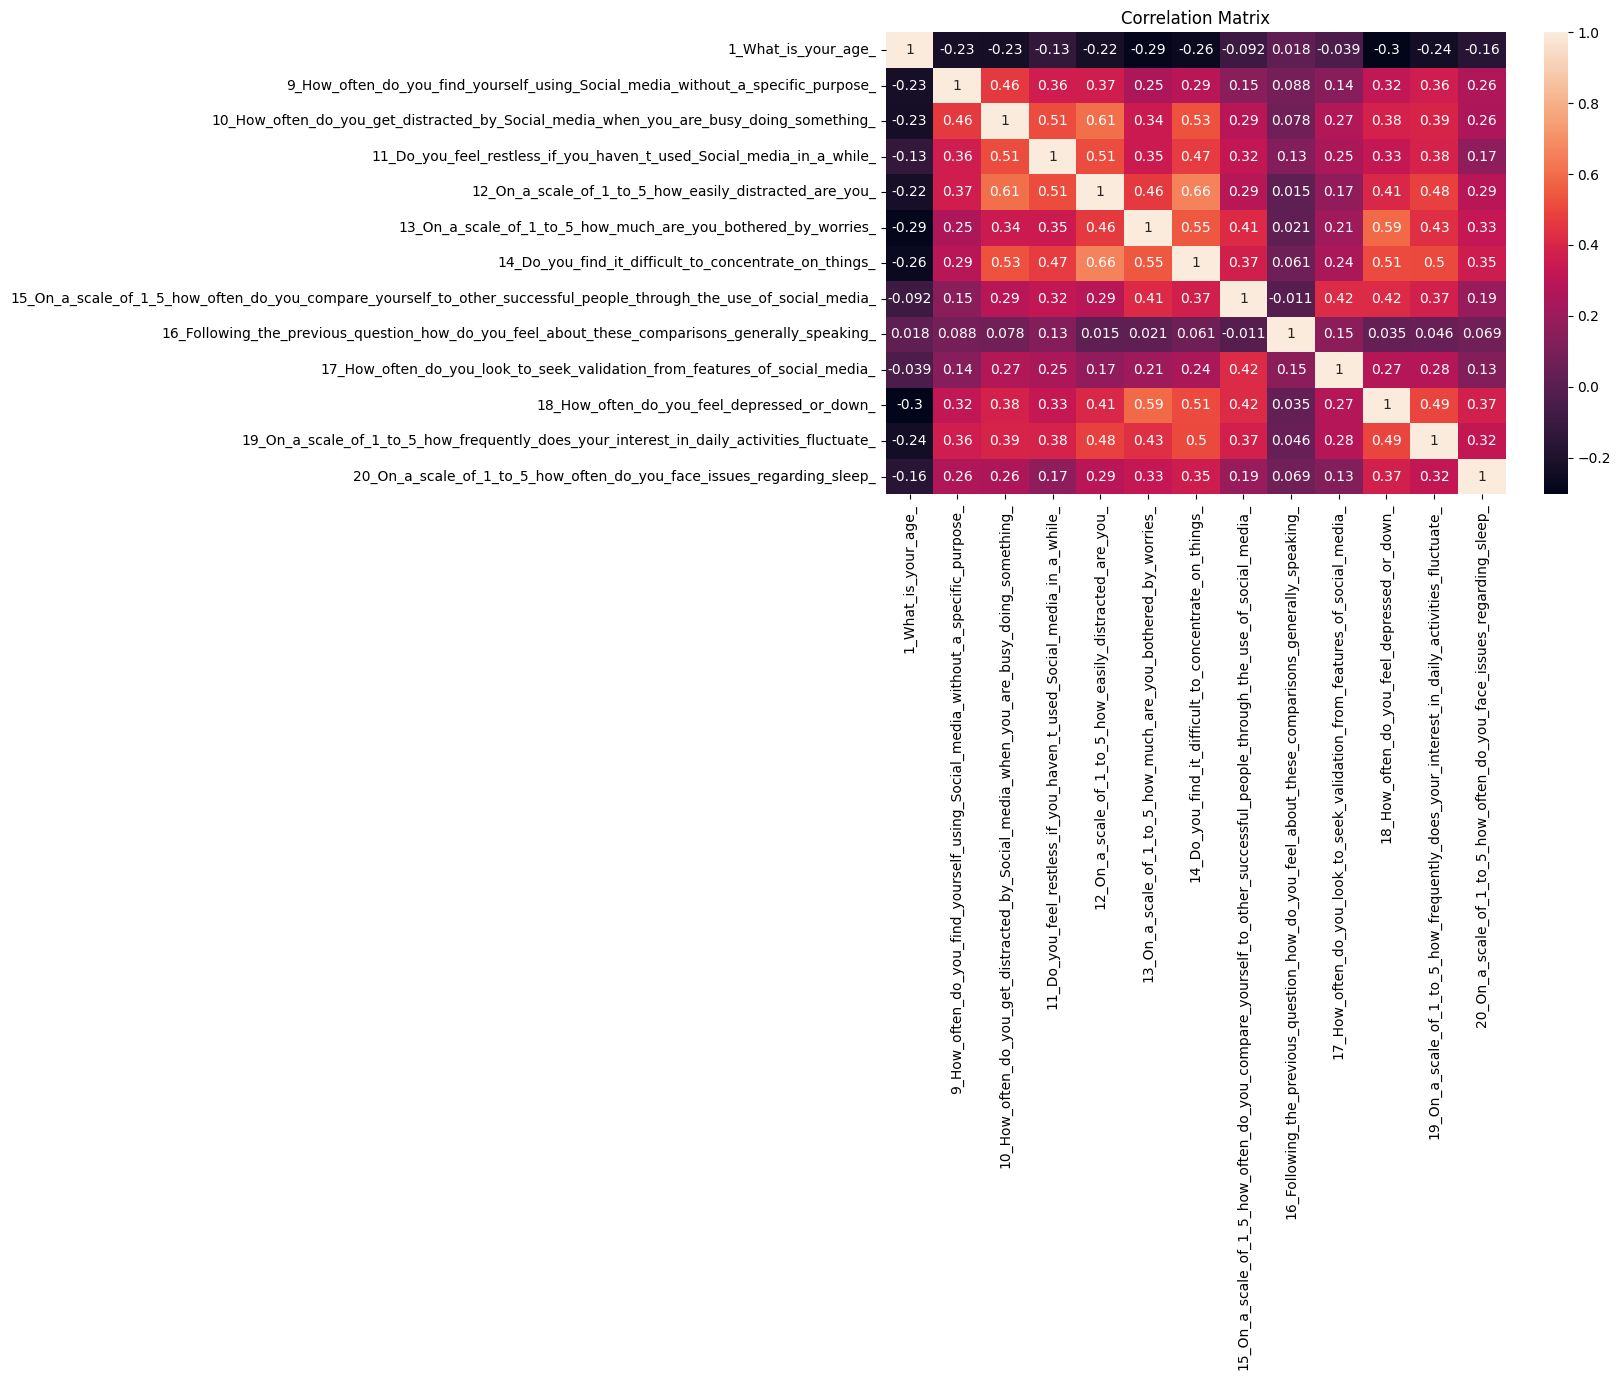

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# 7. Feature engineering

In [12]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 8.Define Target Variable



In [13]:
target = df.columns[-1]

X = df.drop(columns=[target])
y = df[target]

# 9. Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# 10. Feature scaling

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 11. Model training

### Decision Tree

In [16]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### Random Forest

In [17]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### KNN

In [18]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

### Gradient Boosting

In [19]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

# 12. Hyperparameter Tuning (GridSearchCV)

In [20]:
param_grid = {
'n_estimators':[100,200],
'max_depth':[5,10,20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


# 13.Model Evaluation

In [21]:
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_gb = accuracy_score(y_test, y_pred_gb)

print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)
print("KNN:", acc_knn)
print("Gradient Boosting:", acc_gb)

Decision Tree: 0.28865979381443296
Random Forest: 0.32989690721649484
KNN: 0.27835051546391754
Gradient Boosting: 0.23711340206185566


# 14. Model Comparison

In [22]:
results = pd.DataFrame({
"Model":["Decision Tree","Random Forest","KNN","Gradient Boosting"],
"Accuracy":[acc_dt, acc_rf, acc_knn, acc_gb]
})

print(results)

               Model  Accuracy
0      Decision Tree  0.288660
1      Random Forest  0.329897
2                KNN  0.278351
3  Gradient Boosting  0.237113


# 15.Accuracy Graph

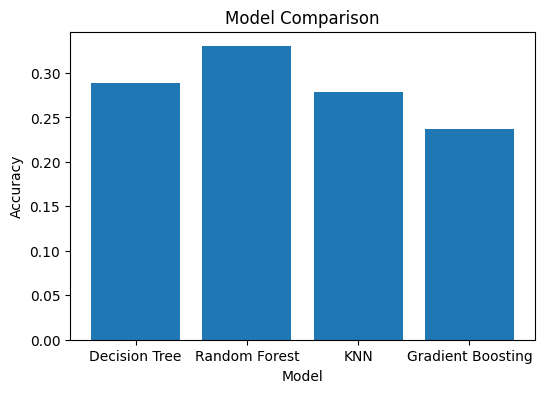

In [23]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

# 16. Confusion Matrix

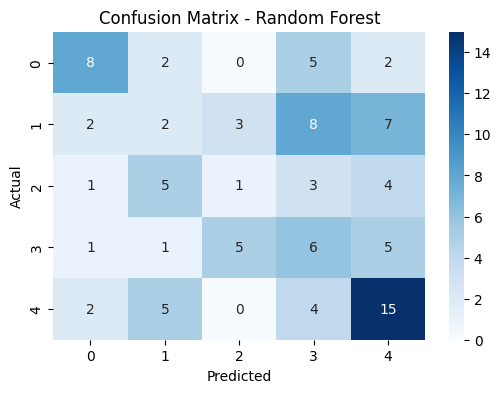

In [24]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 17. Classification Report

In [25]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.57      0.47      0.52        17
           2       0.13      0.09      0.11        22
           3       0.11      0.07      0.09        14
           4       0.23      0.33      0.27        18
           5       0.45      0.58      0.51        26

    accuracy                           0.33        97
   macro avg       0.30      0.31      0.30        97
weighted avg       0.31      0.33      0.31        97



# 18.Final Result

In [26]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "KNN", "Gradient Boosting"],
    "Accuracy": [acc_dt, acc_rf, acc_knn, acc_gb]
})

# Display results
print("Model Performance Comparison:")
print(results)

# Find best model
best_model = results.loc[results["Accuracy"].idxmax()]

print("\nBest Model:")
print("Model Name:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])

Model Performance Comparison:
               Model  Accuracy
0      Decision Tree  0.288660
1      Random Forest  0.329897
2                KNN  0.278351
3  Gradient Boosting  0.237113

Best Model:
Model Name: Random Forest
Accuracy: 0.32989690721649484


In [27]:
print(df.columns)

Index(['Timestamp', '1_What_is_your_age_', '2_Gender', '3_Relationship_Status',
       '4_Occupation_Status',
       '5_What_type_of_organizations_are_you_affiliated_with_',
       '6_Do_you_use_social_media_',
       '7_What_social_media_platforms_do_you_commonly_use_',
       '8_What_is_the_average_time_you_spend_on_social_media_every_day_',
       '9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose_',
       '10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something_',
       '11_Do_you_feel_restless_if_you_haven_t_used_Social_media_in_a_while_',
       '12_On_a_scale_of_1_to_5_how_easily_distracted_are_you_',
       '13_On_a_scale_of_1_to_5_how_much_are_you_bothered_by_worries_',
       '14_Do_you_find_it_difficult_to_concentrate_on_things_',
       '15_On_a_scale_of_1_5_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media_',
       '16_Following_the_previous_question_how_do_you_feel_abou

In [32]:
target_col = df.columns[-1]   # last column as target

X = df.drop(target_col, axis=1)
y = df[target_col]

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = RandomForestClassifier()

# Train model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
print(df.columns)

Index(['1_What_is_your_age_', '2_Gender', '3_Relationship_Status',
       '4_Occupation_Status',
       '5_What_type_of_organizations_are_you_affiliated_with_',
       '6_Do_you_use_social_media_',
       '7_What_social_media_platforms_do_you_commonly_use_',
       '8_What_is_the_average_time_you_spend_on_social_media_every_day_',
       '9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose_',
       '10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something_',
       '11_Do_you_feel_restless_if_you_haven_t_used_Social_media_in_a_while_',
       '12_On_a_scale_of_1_to_5_how_easily_distracted_are_you_',
       '13_On_a_scale_of_1_to_5_how_much_are_you_bothered_by_worries_',
       '14_Do_you_find_it_difficult_to_concentrate_on_things_',
       '15_On_a_scale_of_1_5_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media_',
       '16_Following_the_previous_question_how_do_you_feel_about_these_compa

In [50]:
target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

print("Total features:", len(X.columns))  # should be 19

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

Total features: 19


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("mental_health_model.pkl")
feature_columns = joblib.load("train_feature_columns.pkl")

In [54]:
age = st.number_input("Age", 1, 100)
gender = st.selectbox("Gender", [0, 1])
stress = st.slider("Stress Level", 0, 10)

2026-03-17 12:12:10.022 
  command:

    streamlit run C:\Users\sneha\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-17 12:12:10.024 Session state does not function when running a script without `streamlit run`


In [55]:
input_data = {
    "Age": age,
    "Gender": gender,
    "Stress": stress
}

input_df = pd.DataFrame([input_data])

In [56]:
input_df = input_df.reindex(columns=feature_columns, fill_value=0)

In [57]:
if st.button("Predict"):
    prediction = model.predict(input_df)
    st.write("Prediction:", prediction[0])